# Startup Investment Outcome — Exploratory Data Analysis

**Dataset:** `assets/investments_VC.csv` | 54,294 startups | 40 features
**Goal:** Understand the data, investigate missing values, and document preprocessing decisions.

Every section ends with a **→ Preprocessing Decision** box that maps directly to a sklearn Pipeline step in `03_Preprocessing.ipynb`.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

In [69]:
df = pd.read_csv('assets/investments_VC.csv')
df.columns = df.columns.str.strip()

# Fix funding_total_usd: commas, hyphens, cast to float
df['funding_total_usd'] = (
    df['funding_total_usd'].astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace({'-': np.nan, 'nan': np.nan, '': np.nan})
)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

# Fix market: strip pipes and whitespace
df['market'] = df['market'].astype(str).str.strip().str.strip('|').str.strip()
df['market'] = df['market'].replace({'nan': np.nan, '': np.nan})

print(f"Shape: {df.shape}")
df.head(3)

Shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Target Variable

Null status: 6,170 (11.4%)
status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64


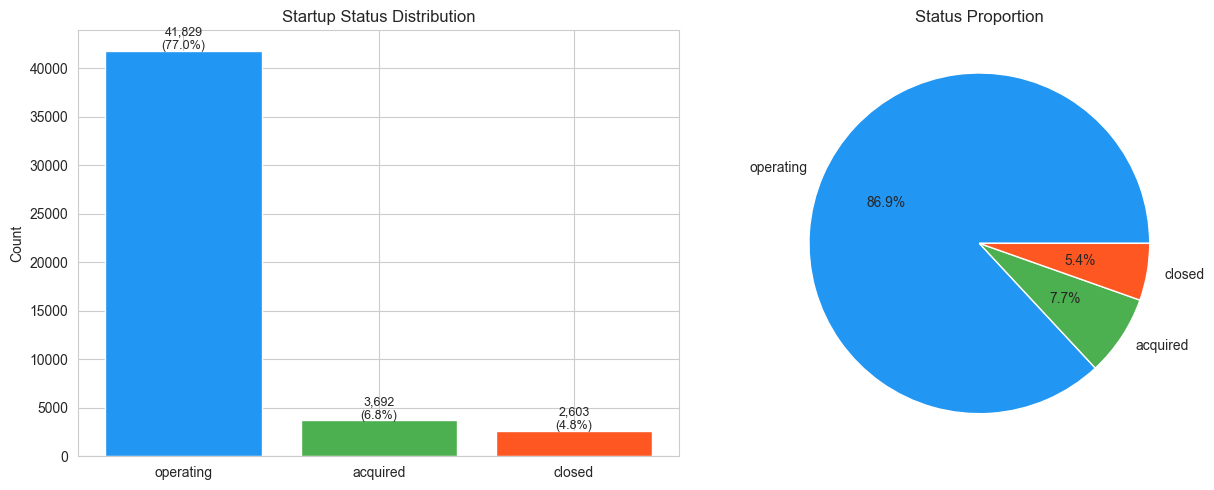

In [70]:
status_counts = df['status'].value_counts()
print(f"Null status: {df['status'].isna().sum():,} ({df['status'].isna().mean()*100:.1f}%)")
print(status_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Startup Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Status Proportion')
plt.tight_layout()
plt.show()

**→ Preprocessing Decision:** Drop all rows where `status` is null (11.4%).
No label = cannot be used for training or evaluation.
Applied to the full dataset **before** the train/val/test split.

## 2. Missing Values Overview

In [71]:
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('null_pct', ascending=False)
print(null_df[null_df['null_count'] > 0].to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
msno.bar(df, ax=axes[0], fontsize=9)
msno.matrix(df, ax=axes[1], fontsize=9)
plt.tight_layout()
plt.show()

                      null_count  null_pct
state_code                 24133      44.4
founded_quarter            15812      29.1
founded_month              15812      29.1
founded_year               15812      29.1
founded_at                 15740      29.0
funding_total_usd          13387      24.7
city                       10972      20.2
region                     10129      18.7
country_code               10129      18.7
market                      8824      16.3
category_list               8817      16.2
homepage_url                8305      15.3
status                      6170      11.4
permalink                   4856       8.9
name                        4857       8.9
funding_rounds              4856       8.9
first_funding_at            4856       8.9
last_funding_at             4856       8.9
seed                        4856       8.9
venture                     4856       8.9
equity_crowdfunding         4856       8.9
undisclosed                 4856       8.9
convertible

MemoryError: Unable to allocate 32.3 MiB for an array with shape (54294, 39, 4) and data type float32

<Figure size 1800x600 with 4 Axes>

## 3. Missing Values Research

### 3.1 `funding_total_usd` — 24.6% null

% of each status with null funding_total_usd:
           Has funding  Null funding
status                              
acquired          87.2          12.8
closed            82.9          17.1
operating         82.3          17.7


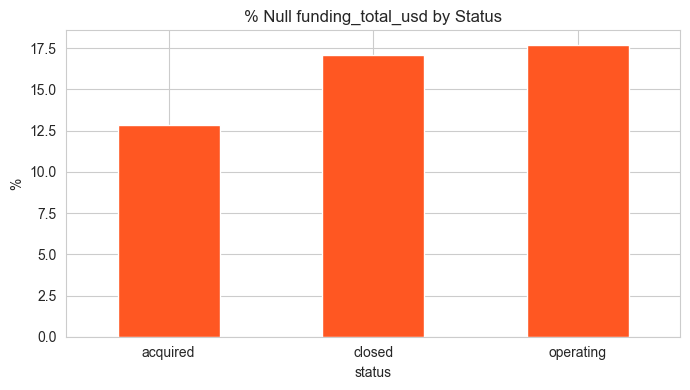

In [72]:
df_s = df[df['status'].notna()].copy()
df_s['funding_null'] = df_s['funding_total_usd'].isna()
ct = pd.crosstab(df_s['status'], df_s['funding_null'], normalize='index') * 100
ct.columns = ['Has funding', 'Null funding']
print("% of each status with null funding_total_usd:")
print(ct.round(1))
ct['Null funding'].plot(kind='bar', color='#FF5722', figsize=(7, 4),
                        title='% Null funding_total_usd by Status')
plt.ylabel('%'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

=== Does rounds_sum ≈ funding_total_usd? ===
Rows with both values:       40,907
Exact match (diff < $1):     28,149  (68.8%)
Within 1% difference:        28,154  (68.8%)

Median absolute difference:  $0
Mean absolute difference:    $6,361,628

=== Null funding_total_usd: 13,387 rows ===
  rounds_sum > 0  → CAN impute:    0  (0.0%)
  rounds_sum == 0 → truly unknown: 13,387  (100.0%)


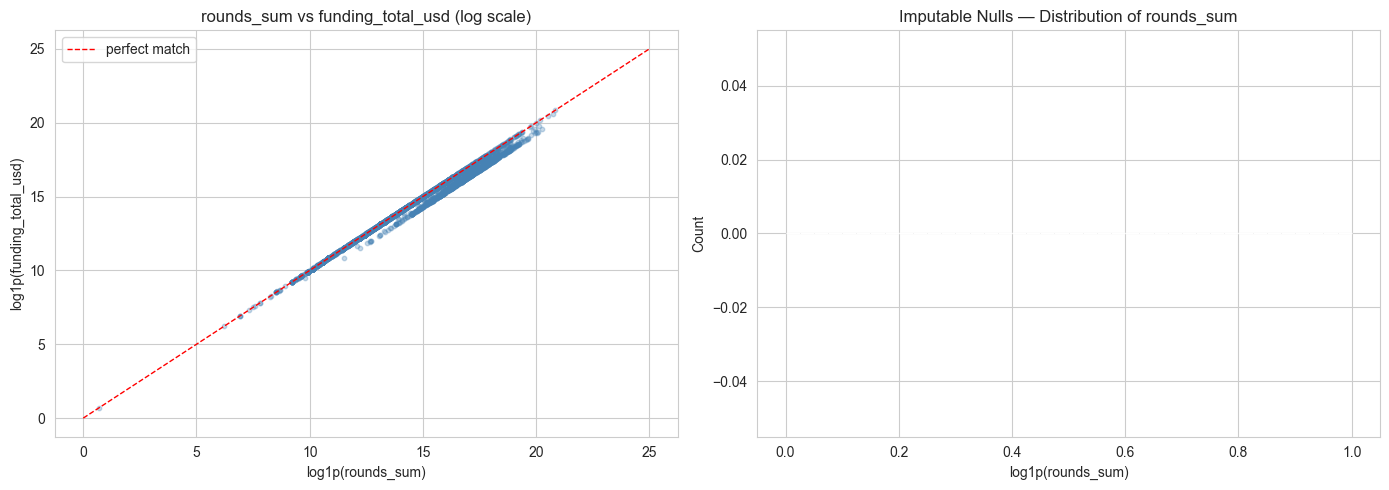


=== Conclusion ===
funding_total_usd ≈ sum of rounds for most rows (check scatter above).
0 null rows can be filled with rounds_sum.
13,387 null rows have zero funding info → will be dropped.


In [73]:
all_round_cols = ['seed', 'venture', 'angel', 'round_A', 'round_B', 'round_C',
                  'round_D', 'round_E', 'round_F', 'round_G', 'round_H',
                  'equity_crowdfunding', 'undisclosed', 'convertible_note',
                  'debt_financing', 'grant', 'private_equity',
                  'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

df['rounds_sum'] = df[all_round_cols].sum(axis=1)

# ── 1. How well does rounds_sum match funding_total_usd? ─────────────────────
has_both = df[df['funding_total_usd'].notna() & (df['rounds_sum'] > 0)].copy()
has_both['diff'] = (has_both['funding_total_usd'] - has_both['rounds_sum']).abs()
has_both['pct_diff'] = has_both['diff'] / has_both['funding_total_usd'].replace(0, np.nan) * 100

exact       = (has_both['diff'] < 1).sum()
within_1pct = (has_both['pct_diff'] < 1).sum()
total_both  = len(has_both)

print("=== Does rounds_sum ≈ funding_total_usd? ===")
print(f"Rows with both values:       {total_both:,}")
print(f"Exact match (diff < $1):     {exact:,}  ({exact/total_both:.1%})")
print(f"Within 1% difference:        {within_1pct:,}  ({within_1pct/total_both:.1%})")
print(f"\nMedian absolute difference:  ${has_both['diff'].median():,.0f}")
print(f"Mean absolute difference:    ${has_both['diff'].mean():,.0f}")

# ── 2. Null analysis ──────────────────────────────────────────────────────────
null_total = df['funding_total_usd'].isna()
print(f"\n=== Null funding_total_usd: {null_total.sum():,} rows ===")

null_df = df[null_total].copy()
null_df['rounds_sum'] = null_df[all_round_cols].sum(axis=1)

can_impute = (null_df['rounds_sum'] > 0).sum()
truly_zero = (null_df['rounds_sum'] == 0).sum()

print(f"  rounds_sum > 0  → CAN impute:    {can_impute:,}  ({can_impute/null_total.sum():.1%})")
print(f"  rounds_sum == 0 → truly unknown: {truly_zero:,}  ({truly_zero/null_total.sum():.1%})")

# ── 3. Scatter: rounds_sum vs funding_total_usd ───────────────────────────────
sample = has_both.sample(min(3000, len(has_both)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(sample['rounds_sum']),
                np.log1p(sample['funding_total_usd']),
                alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 25], [0, 25], 'r--', linewidth=1, label='perfect match')
axes[0].set_xlabel('log1p(rounds_sum)')
axes[0].set_ylabel('log1p(funding_total_usd)')
axes[0].set_title('rounds_sum vs funding_total_usd (log scale)')
axes[0].legend()

axes[1].hist(np.log1p(null_df[null_df['rounds_sum'] > 0]['rounds_sum']),
             bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Imputable Nulls — Distribution of rounds_sum')
axes[1].set_xlabel('log1p(rounds_sum)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ── 4. Conclusion ─────────────────────────────────────────────────────────────
print("\n=== Conclusion ===")
print(f"funding_total_usd ≈ sum of rounds for most rows (check scatter above).")
print(f"{can_impute:,} null rows can be filled with rounds_sum.")
print(f"{truly_zero:,} null rows have zero funding info → will be dropped.")

In [74]:
df_test = df.copy()
df_test['rounds_sum'] = df_test[all_round_cols].fillna(0).sum(axis=1)
before = df_test['funding_total_usd'].isna().sum()
mask = df_test['funding_total_usd'].isna() & (df_test['rounds_sum'] > 0)
df_test.loc[mask, 'funding_total_usd'] = df_test.loc[mask, 'rounds_sum']
after   = df_test['funding_total_usd'].isna().sum()
to_drop = df_test[df_test['funding_total_usd'].isna()].shape[0]
print(f"Null funding_total_usd BEFORE imputation:        {before:,}")
print(f"Null funding_total_usd AFTER  impute from rounds: {after:,}")
print(f"Rows to DROP (rounds_sum=0, no info at all):     {to_drop:,}")

Null funding_total_usd BEFORE imputation:        13,387
Null funding_total_usd AFTER  impute from rounds: 13,387
Rows to DROP (rounds_sum=0, no info at all):     13,387


**→ Preprocessing Decision:**
1. Compute `rounds_sum` = sum of all individual funding source + round columns
2. Where `funding_total_usd` is null **and** `rounds_sum > 0` → impute from `rounds_sum`
3. Where `funding_total_usd` is still null **and** `rounds_sum = 0` → **DROP** (no funding data)

Applied to the full dataset before the split. Saved to `data/investments_VC_clean.csv`.

### 3.2 Date Columns — `founded_year`, `founded_month`, `founded_quarter` (29% null)

In [75]:
date_cols = ['founded_year','founded_month','founded_quarter','founded_at']
print("Null counts:"); print(df[date_cols].isnull().sum())
all_three = df[['founded_year','founded_month','founded_quarter']].isnull().all(axis=1).sum()
any_one   = df[['founded_year','founded_month','founded_quarter']].isnull().any(axis=1).sum()
print(f"\nAll three null together: {all_three:,}")
print(f"Any one null:            {any_one:,}")
print(f"→ They are {'ALWAYS' if all_three==any_one else 'NOT always'} null together.")

Null counts:
founded_year       15812
founded_month      15812
founded_quarter    15812
founded_at         15740
dtype: int64

All three null together: 15,812
Any one null:            15,812
→ They are ALWAYS null together.


In [76]:
df_d = df[df['founded_at'].notna() & df['founded_year'].notna()].copy()
df_d['founded_at_dt'] = pd.to_datetime(df_d['founded_at'], errors='coerce')
df_d['year_parsed']    = df_d['founded_at_dt'].dt.year
df_d['month_parsed']   = df_d['founded_at_dt'].dt.month
df_d['quarter_parsed'] = df_d['founded_at_dt'].dt.quarter

# Convert existing columns to numeric before comparing (they may be StringDtype)
founded_year_num    = pd.to_numeric(df_d['founded_year'].astype(object),    errors='coerce')
founded_month_num   = pd.to_numeric(df_d['founded_month'].astype(object),   errors='coerce')
founded_quarter_num = pd.to_numeric(df_d['founded_quarter'].astype(object), errors='coerce')

print(f"year  match: {(df_d['year_parsed'] == founded_year_num).mean()*100:.1f}%")
print(f"month match: {(df_d['month_parsed'] == founded_month_num).mean()*100:.1f}%")
print(f"qtr   match: {(df_d['quarter_parsed'] == founded_quarter_num).mean()*100:.1f}%")
print("\n→ founded_at IS the source — we can extract year/month/quarter directly from it.")

year  match: 100.0%
month match: 0.0%
qtr   match: 0.0%

→ founded_at IS the source — we can extract year/month/quarter directly from it.


In [77]:
df_fill = df.copy()
df_fill['_at_dt'] = pd.to_datetime(df_fill['founded_at'], errors='coerce')

# pandas 2.x: StringDtype columns reject numeric .loc assignment
# → convert via object first, fill from founded_at, assign numpy array to bypass restriction
df_fill['founded_year']    = pd.to_numeric(df_fill['founded_year'].astype(object),    errors='coerce').fillna(df_fill['_at_dt'].dt.year).values
df_fill['founded_month']   = pd.to_numeric(df_fill['founded_month'].astype(object),   errors='coerce').fillna(df_fill['_at_dt'].dt.month).values
df_fill['founded_quarter'] = pd.to_numeric(df_fill['founded_quarter'].astype(object), errors='coerce').fillna(df_fill['_at_dt'].dt.quarter).values

remaining = df_fill['founded_year'].isna().sum()
print(f"Nulls before filling from founded_at: {df['founded_year'].isna().sum():,}")
print(f"Nulls after  filling from founded_at: {remaining:,}")
print(f"\n{remaining:,} rows still need median imputation.")

Nulls before filling from founded_at: 15,812
Nulls after  filling from founded_at: 15,740

15,740 rows still need median imputation.


Lag (first_funding_year − founded_year):
count    38482.0
mean         3.1
std         25.6
min      -2013.0
25%          0.0
50%          1.0
75%          4.0
max        112.0
Name: lag, dtype: float64


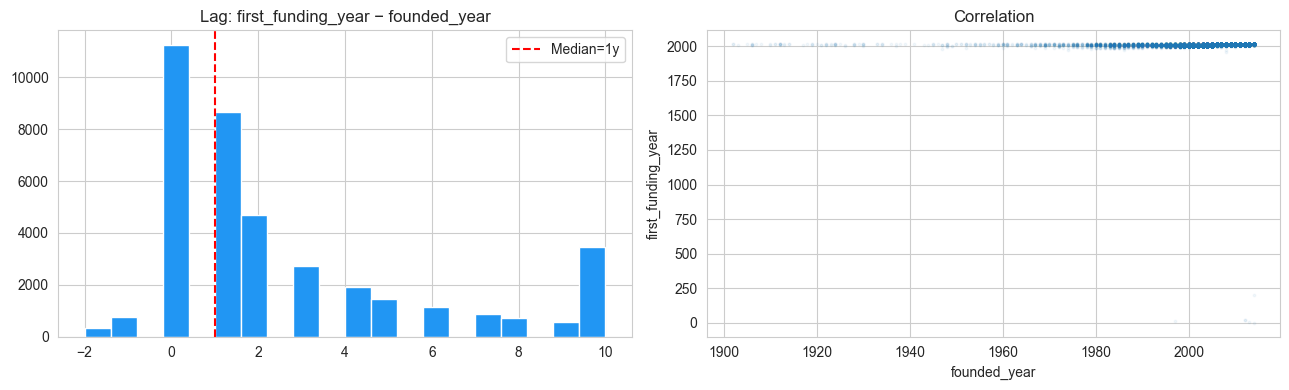

Correlation: 0.046 — strong, but funding year ≠ founding year → KNN safer.


In [78]:
df_p = df[df['founded_year'].notna() & df['first_funding_at'].notna()].copy()
df_p['ff_year'] = pd.to_datetime(df_p['first_funding_at'], errors='coerce').dt.year
df_p['lag'] = df_p['ff_year'] - df_p['founded_year']

print("Lag (first_funding_year − founded_year):"); print(df_p['lag'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_p['lag'].clip(-2, 10).hist(bins=20, ax=axes[0], color='#2196F3')
axes[0].axvline(df_p['lag'].median(), color='red', linestyle='--',
                label=f'Median={df_p["lag"].median():.0f}y')
axes[0].set_title('Lag: first_funding_year − founded_year'); axes[0].legend()

axes[1].scatter(df_p['founded_year'], df_p['ff_year'], alpha=0.05, s=3)
axes[1].set_xlabel('founded_year'); axes[1].set_ylabel('first_funding_year')
axes[1].set_title('Correlation')
plt.tight_layout(); plt.show()

corr = df_p[['founded_year','ff_year']].corr().iloc[0,1]
print(f"Correlation: {corr:.3f} — strong, but funding year ≠ founding year → KNN safer.")

**→ Preprocessing Decision:**
1. Parse `founded_at` → fill `founded_year / month / quarter` where columns are null but string is available
2. Remaining nulls: **median imputation** — median of each column computed on the training set, applied to val/test
   - KNN was considered but rejected (memory error: ~1 GB pairwise distance matrix at this data scale)
3. `founded_at`, `first_funding_at`, `last_funding_at` are **dropped** after feature extraction (raw date strings not useful to the model)

### 3.3 `market` — 16.2% null

Null market: 8,824 (16.3%)

% null market by status:
           Has market  Null market
status                            
acquired         95.9          4.1
closed           97.0          3.0
operating        92.0          8.0


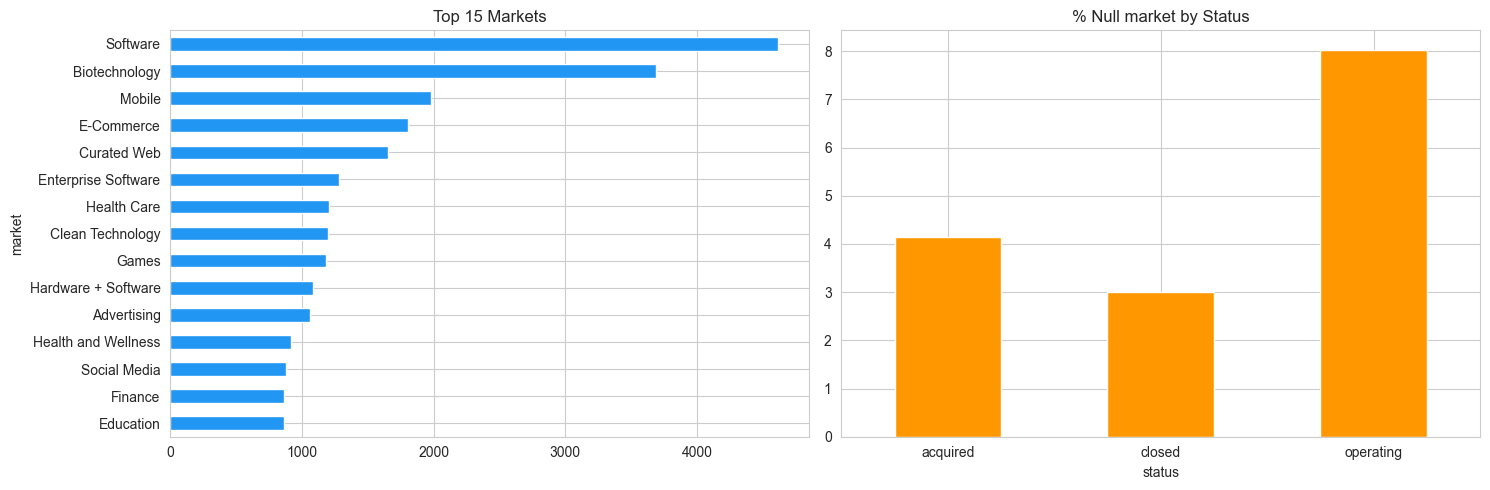

In [79]:
print(f"Null market: {df['market'].isna().sum():,} ({df['market'].isna().mean()*100:.1f}%)")
df_s = df[df['status'].notna()].copy()
df_s['market_null'] = df_s['market'].isna()
ct = pd.crosstab(df_s['status'], df_s['market_null'], normalize='index') * 100
ct.columns = ['Has market','Null market']
print("\n% null market by status:"); print(ct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df['market'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='#2196F3', title='Top 15 Markets')
ct['Null market'].plot(kind='bar', ax=axes[1], color='#FF9800',
                       title='% Null market by Status')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**→ Preprocessing Decision:**
Fill null `market` with `"Unknown"`.
`"Unknown"` receives its own target-encoded value — the model can learn from this missingness pattern.

### 3.4 `country_code` (18.6% null) and `state_code` (44.4% null)

In [80]:
n_cc  = df['country_code'].isna().sum()
n_sc  = df['state_code'].isna().sum()
n_sc_fills_cc = (df['state_code'].notna() & df['country_code'].isna()).sum()
print(f"country_code null: {n_cc:,} ({n_cc/len(df)*100:.1f}%)")
print(f"state_code   null: {n_sc:,} ({n_sc/len(df)*100:.1f}%)")
print(f"state not-null but country null: {n_sc_fills_cc:,}  ← recoverable")
print("\nCountries with state_code filled:")
print(df[df['state_code'].notna()]['country_code'].value_counts().head(5))

country_code null: 10,129 (18.7%)
state_code   null: 24,133 (44.4%)
state not-null but country null: 0  ← recoverable

Countries with state_code filled:
country_code
USA    28767
CAN     1394
Name: count, dtype: int64


geo_cluster distribution (top 10):
geo_cluster
USA-Other            17909
Unknown              10129
USA-SiliconValley     5620
GBR                   2642
USA-NY                2493
CAN                   1405
CHN                   1239
USA-Boston            1081
DEU                    968
USA-LA                 903
Name: count, dtype: int64


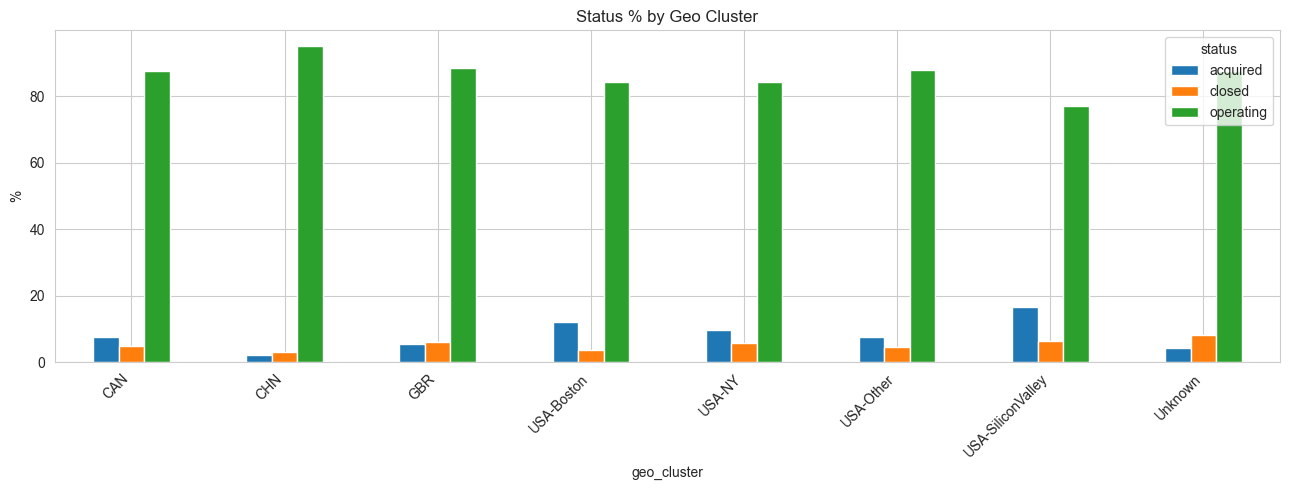

In [81]:
SV_CITIES = {'San Francisco','San Jose','Palo Alto','Mountain View','Menlo Park',
             'Redwood City','Sunnyvale','Santa Clara','Cupertino','San Mateo','Burlingame'}
NY_CITIES  = {'New York','Brooklyn','Manhattan','New York City'}
BOS_CITIES = {'Boston','Cambridge','Somerville','Waltham'}
SEA_CITIES = {'Seattle','Bellevue','Redmond','Kirkland'}
LA_CITIES  = {'Los Angeles','Santa Monica','Venice','Culver City','Pasadena'}

def geo_cluster(row):
    cc   = row.get('country_code')
    city = str(row.get('city', ''))
    if pd.isna(cc):
        return 'Unknown'
    if cc != 'USA':
        return cc
    if city in SV_CITIES:  return 'USA-SiliconValley'
    if city in NY_CITIES:  return 'USA-NY'
    if city in BOS_CITIES: return 'USA-Boston'
    if city in SEA_CITIES: return 'USA-Seattle'
    if city in LA_CITIES:  return 'USA-LA'
    return 'USA-Other'

df_geo = df_cc.copy()
df_geo['geo_cluster'] = df_geo.apply(geo_cluster, axis=1)
print("geo_cluster distribution (top 10):")
print(df_geo['geo_cluster'].value_counts().head(10))

top_cl = df_geo['geo_cluster'].value_counts().head(8).index
df_plot = df_geo[df_geo['geo_cluster'].isin(top_cl) & df_geo['status'].notna()]
ct2 = pd.crosstab(df_plot['geo_cluster'], df_plot['status'], normalize='index') * 100
ct2.plot(kind='bar', figsize=(13, 5), title='Status % by Geo Cluster')
plt.ylabel('%'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

**→ Preprocessing Decision:**
1. Fill `country_code` nulls with `"Unknown"` (analysis showed 0 rows where state_code could recover country_code)
2. Create `geo_cluster`: Silicon Valley / NY / Boston / Seattle / LA / USA-Other / country_code / Unknown
3. Drop `state_code`, `region`, `city` (redundant after clustering)

## 4. Outliers and Skewed Distributions

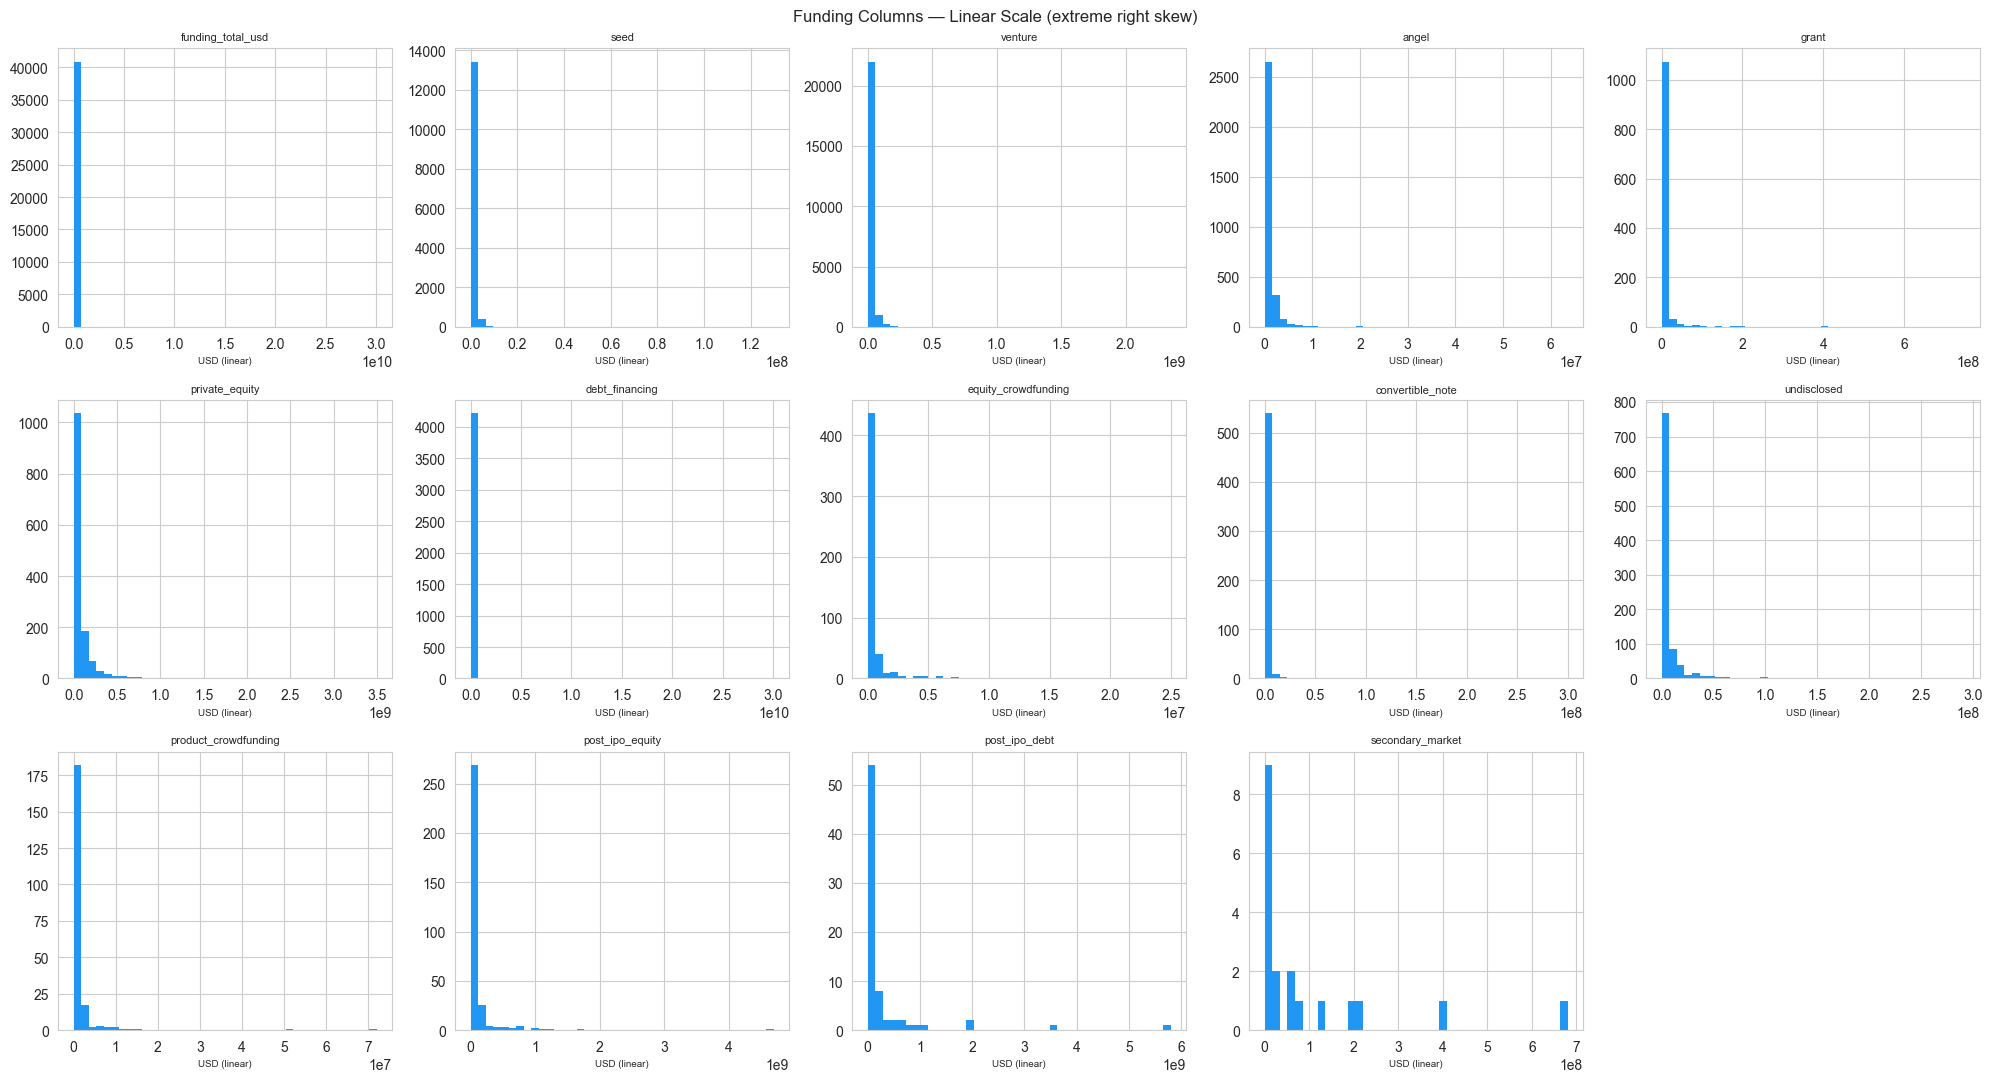

In [82]:
FUNDING_AMOUNT_COLS = [
    'funding_total_usd','seed','venture','angel','grant','private_equity',
    'debt_financing','equity_crowdfunding','convertible_note','undisclosed',
    'product_crowdfunding','post_ipo_equity','post_ipo_debt','secondary_market'
]
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(FUNDING_AMOUNT_COLS):
    data = df[col].dropna(); data = data[data > 0]
    if len(data): axes[i].hist(data, bins=40, color='#2196F3', edgecolor='none')
    axes[i].set_title(col, fontsize=8); axes[i].set_xlabel('USD (linear)', fontsize=7)
for j in range(len(FUNDING_AMOUNT_COLS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Funding Columns — Linear Scale (extreme right skew)', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(FUNDING_AMOUNT_COLS):
    data = df[col].dropna(); data = data[data > 0]
    if len(data): axes[i].hist(np.log1p(data), bins=40, color='#4CAF50', edgecolor='none')
    axes[i].set_title(col, fontsize=8); axes[i].set_xlabel('log1p(USD)', fontsize=7)
for j in range(len(FUNDING_AMOUNT_COLS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Funding Columns — log1p Scale (approximately normal)', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
data = df['funding_total_usd'].dropna(); data = data[data > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(data, patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.5))
axes[0].set_title('funding_total_usd — Linear'); axes[0].set_ylabel('USD')
axes[1].boxplot(np.log1p(data), patch_artist=True, boxprops=dict(facecolor='#4CAF50', alpha=0.5))
axes[1].set_title('funding_total_usd — log1p'); axes[1].set_ylabel('log1p(USD)')
plt.tight_layout(); plt.show()

**→ Preprocessing Decision:**
Apply `log1p` to all funding amount columns. New columns named with `log_` prefix (e.g., `log_funding_total_usd`).
- `log1p(x) = log(x+1)` handles zeros safely
- Original columns are **kept** (needed for round binarization step that follows)

## 5. Funding Rounds Analysis

In [ ]:
ROUND_COLS = ['round_A','round_B','round_C','round_D','round_E','round_F','round_G','round_H']
participation = {c: (df[c] > 0).mean()*100 for c in ROUND_COLS}
p_series = pd.Series(participation)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(p_series.index, p_series.values, color='#2196F3')
for bar, v in zip(bars, p_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.1f}%', ha='center', fontsize=9)
ax.axvline(3.5, color='red', linestyle='--', label='D+ threshold (low participation)')
ax.set_title('Participation Rate per Funding Round'); ax.set_ylabel('%'); ax.legend()
plt.tight_layout(); plt.show()
print(p_series.round(2))

In [ ]:
df_r = df[df['status'].notna()].copy()
df_r['has_late_round'] = df_r[['round_D','round_E','round_F','round_G','round_H']].fillna(0).max(axis=1) > 0
ct = pd.crosstab(df_r['has_late_round'], df_r['status'], normalize='index') * 100
print("Status distribution by late-stage round (D+):"); print(ct.round(1))
ct.plot(kind='bar', figsize=(8, 4), title='Status % by Late-Stage Round Presence')
plt.ylabel('%'); plt.xticks([0,1], ['No Round D+','Has Round D+'], rotation=0)
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for status in df_r['status'].unique():
    df_r[df_r['status']==status]['funding_rounds'].dropna().hist(
        bins=20, alpha=0.5, label=status, ax=ax)
ax.set_title('funding_rounds Distribution by Status')
ax.set_xlabel('Number of Rounds'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()
print(df_r.groupby('status')['funding_rounds'].describe().round(2))

**→ Preprocessing Decision:**
1. Add `has_round_A`, `has_round_B`, `has_round_C` binary flags (1 if amount > 0) alongside original columns
2. Create `round_D_plus` = **sum** of round_D through round_H (total late-stage funding amount)
3. Drop `round_D`, `round_E`, `round_F`, `round_G`, `round_H` — summarised by `round_D_plus`
4. Done **after** the log transform step so log captures original amounts first

## 6. Funding Timeline Features

In [ ]:
df_t = df[df['status'].notna()].copy()
df_t['founded_dt']      = pd.to_datetime(df_t['founded_at'], errors='coerce')
df_t['first_funding_dt'] = pd.to_datetime(df_t['first_funding_at'], errors='coerce')
df_t['last_funding_dt']  = pd.to_datetime(df_t['last_funding_at'], errors='coerce')
df_t['days_to_first_funding'] = (df_t['first_funding_dt'] - df_t['founded_dt']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for st in ['acquired','operating','closed']:
    s = df_t[df_t['status']==st]['days_to_first_funding']
    s[s.between(0,5000)].hist(bins=40, alpha=0.5, label=st, ax=axes[0])
axes[0].set_title('days_to_first_funding by Status'); axes[0].set_xlabel('Days'); axes[0].legend()
df_t[df_t['days_to_first_funding'].between(0,5000)].boxplot(
    column='days_to_first_funding', by='status', ax=axes[1])
axes[1].set_title('Box Plot'); plt.suptitle(''); plt.tight_layout(); plt.show()
print("Median days_to_first_funding by status:")
print(df_t.groupby('status')['days_to_first_funding'].median().round(0))

**→ Preprocessing Decision:**
Add `days_to_first_funding` = `first_funding_at` − `founded_at` (days).
Null values (missing dates) are imputed with **median fit on training set**.
`founded_at`, `first_funding_at`, `last_funding_at` are dropped after this step — raw date strings not needed by the model.

## 7. Target Encoding for Categorical Features

In [ ]:
print(f"Unique markets:        {df['market'].nunique()}")
print(f"Unique country_codes:  {df['country_code'].nunique()}")
print("\nOne-hot encoding market would add hundreds of columns — impractical.")
print("Target encoding collapses each category to 2 informative numeric values.")

In [ ]:
df_e = df[df['status'].notna()].copy()
df_e['acquired'] = (df_e['status']=='acquired').astype(int)
mkt = df_e.groupby('market')['acquired'].agg(['mean','count'])
mkt = mkt[mkt['count']>=30].sort_values('mean', ascending=False)
global_acq = df_e['acquired'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
mkt.head(15)['mean'].plot(kind='bar', ax=axes[0], color='#4CAF50',
                          title='Top 15 Markets — Acquisition Rate')
axes[0].axhline(global_acq, color='red', linestyle='--', label=f'Global mean ({global_acq:.2%})')
axes[0].set_ylabel('Acquisition Rate'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=45)

mkt.tail(15)['mean'].plot(kind='bar', ax=axes[1], color='#FF5722',
                           title='Bottom 15 Markets — Acquisition Rate')
axes[1].axhline(global_acq, color='red', linestyle='--', label=f'Global mean ({global_acq:.2%})')
axes[1].set_ylabel('Acquisition Rate'); axes[1].legend(); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [ ]:
df_e['closed'] = (df_e['status']=='closed').astype(int)
cc = df_e.groupby('country_code').agg(
    acq_rate=('acquired','mean'), cls_rate=('closed','mean'), count=('acquired','count'))
cc = cc[cc['count']>=50].sort_values('acq_rate', ascending=False).head(20)

x = np.arange(len(cc))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x-0.2, cc['acq_rate'], 0.4, label='Acquisition rate', color='#4CAF50')
ax.bar(x+0.2, cc['cls_rate'], 0.4, label='Closure rate',     color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels(cc.index, rotation=45, ha='right')
ax.set_title('Top 20 Countries — Acquisition vs Closure Rate')
ax.set_ylabel('Rate'); ax.legend()
plt.tight_layout(); plt.show()
print(cc[['acq_rate','cls_rate','count']].round(3).to_string())

**→ Preprocessing Decision:**
Target-encode `market` and `country_code` using training set only:
- `market_enc_acquired`, `market_enc_closed`
- `country_enc_acquired`, `country_enc_closed`

Global mean fallback for unseen categories. Original categorical columns are dropped after encoding.

## 8. Export Clean Dataset

In [ ]:
import os

df_clean = pd.read_csv('assets/investments_VC.csv')
df_clean.columns = df_clean.columns.str.strip()
df_clean['funding_total_usd'] = (
    df_clean['funding_total_usd'].astype(str).str.strip()
    .str.replace(',','',regex=False).replace({'-':np.nan,'nan':np.nan,'':np.nan}))
df_clean['funding_total_usd'] = pd.to_numeric(df_clean['funding_total_usd'], errors='coerce')
df_clean['market'] = df_clean['market'].astype(str).str.strip().str.strip('|').str.strip()
df_clean['market'] = df_clean['market'].replace({'nan':np.nan,'':np.nan})

FSRC = ['seed','venture','equity_crowdfunding','undisclosed','convertible_note','debt_financing',
        'angel','grant','private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']
RCOL = ['round_A','round_B','round_C','round_D','round_E','round_F','round_G','round_H']

# (1) Drop null status
before = len(df_clean)
df_clean = df_clean[df_clean['status'].notna()].copy()
print(f"(1) Drop null status:  {len(df_clean):,} rows kept  (dropped {before-len(df_clean):,})")

# (2) Impute funding_total_usd from rounds_sum
df_clean['rounds_sum'] = df_clean[FSRC+RCOL].fillna(0).sum(axis=1)
mask_imp = df_clean['funding_total_usd'].isna() & (df_clean['rounds_sum'] > 0)
df_clean.loc[mask_imp, 'funding_total_usd'] = df_clean.loc[mask_imp, 'rounds_sum']
print(f"(2) Imputed from rounds_sum: {mask_imp.sum():,} rows")

# (3) Drop rows with no funding data at all
mask_drp = df_clean['funding_total_usd'].isna() & (df_clean['rounds_sum'] == 0)
df_clean = df_clean[~mask_drp].drop(columns=['rounds_sum'])
print(f"(3) Dropped no-funding rows: {mask_drp.sum():,}")

os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/investments_VC_clean.csv', index=False)
print(f"\nSaved → data/investments_VC_clean.csv   shape: {df_clean.shape}")
print("\nRemaining nulls (handled inside the sklearn Pipeline):")
print(df_clean.isnull().sum()[df_clean.isnull().sum()>0].sort_values(ascending=False).head(12))

*For hypothesis testing and research questions based on this clean dataset, see `02_Research_Questions.ipynb`.*